In [1]:
import numpy as np
import sys,os
import scipy.special as sysp
import scipy.signal as sysig
import scipy.linalg as linalg
from pathlib import Path

Base_Dir = './' # assuming we are in zeldovich-smearing/examples/, else modify this
Like_Dir = Base_Dir + '../code/'
sys.path.append(Like_Dir)

from paths import *
sys.path.append(ML_Path)
from mlalgos import BiSequential
from mllib import Utilities

import copy,pickle,json

import gc
from time import time

ut = Utilities()

In [2]:
# These imports needed for MCMC using Cobaya
from cobaya.yaml import yaml_load_file
from cobaya.run import run
from cobaya.log import LoggedError

In [3]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol

from cobaya.model import get_model

from getdist.mcsamples import loadMCSamples
%matplotlib inline  
import getdist.plots as gdplt

mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 16 # 14
mpl.rcParams['legend.labelspacing'] = 0.25

FS = 18
FS2 = 15
FS3 = 13
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3
print('mpl setup done')
#mpl.rcParams.keys()

mpl setup done


***
# BAO Multipole Models
### Analysis of Zel'dovich smearing model with scale-dependent bias and mode coupling
***

## Setup

### Files and folders

In [4]:
Sample = 'DESI-LRG2' # '','DESI-LRG2','Euclid-ELG'
Iteration = 0 
Redshift = 0.8 if Sample != '' else 0.7

Mmin_dict = {'DESI-LRG2':8e12,
             # below are existing tests with 3x DESI volume
             'DESI-LRG2-AP-x3':8e12 if Redshift > 0.5 else 1.25e13,
             'DESI-LRG2-noAP-x3':8e12 if Redshift > 0.5 else 1.25e13}
M_min = Mmin_dict[Sample]

Data_Dir = Base_Dir + 'data/'

# put these in dictionary
Sample_Root = 'AbacusSummit/base_c000/' # 'SDBMC','AbacusSummit/base_c000/'
File_Tail = 'lgMmin{0:.2f}_z{1:.3f}'.format(np.log10(M_min),Redshift) 
# 'sdbmc', 'lgMmin{0:.2f}_z{1:.3f}'.format(np.log10(M_min),Redshift)

if File_Tail == 'sdbmc':
    Iteration = 2 # no iterations needed for sdbmc toy model

Plots_Dir = Base_Dir + 'plots/'
Path(Plots_Dir).mkdir(parents=True,exist_ok=True) # folder to store plots
# Basis_Stem = 'binet/biNN2p' # default imported from paths should be fine for most purposes
Basis_Prior_File = Basis_Root + 'fitcoeffs/biNN2p-LGbs.json'
Cosmo_Prior_File = Basis_Root + 'fitcoeffs/biNN2p-cosmo-s.json'

# don't change default values until alternate data files available
Include_Sig2Obs = True 
L_Max = 3

File_Body = '_LMax{0:d}_'.format(L_Max) + File_Tail
Scales_File = Data_Dir + Sample_Root + Sample + '/xi' + File_Body + '_scales.txt'

Data_File_Xi = Data_Dir + Sample_Root + Sample + '/xi' + File_Body + '.txt'
Cov_File = Data_Dir + Sample_Root + Sample + '/covmat' + File_Body 
if Include_Sig2Obs:
    Data_File_Sig2Obs = Data_Dir + Sample_Root + Sample + '/Sig2obs' + File_Body + '.txt'
    Data_File = copy.deepcopy([Data_File_Sig2Obs,Data_File_Xi])
    Cov_File += '_inclSig2obs'
else:
    Data_File = Data_File_Xi
Cov_File += '.txt' if Iteration >= 2 else '_iter{0:d}.txt'.format(Iteration)

print(' Scales file   : ',Scales_File)
print('   Data file(s): ',Data_File)
print('Cov mat file   : ',Cov_File)

 Scales file   :  ./data/AbacusSummit/base_c000/DESI-LRG2/xi_LMax3_lgMmin12.90_z0.800_scales.txt
   Data file(s):  ['./data/AbacusSummit/base_c000/DESI-LRG2/Sig2obs_LMax3_lgMmin12.90_z0.800.txt', './data/AbacusSummit/base_c000/DESI-LRG2/xi_LMax3_lgMmin12.90_z0.800.txt']
Cov mat file   :  ./data/AbacusSummit/base_c000/DESI-LRG2/covmat_LMax3_lgMmin12.90_z0.800_inclSig2obs_iter0.txt


### Priors and fiducial values

In [5]:
Prior_Signific = 10.0 # see Appendix D of arXiv:2602.14533

fv_prior = [0.26,Prior_Signific*0.009] # [0.26,Prior_Signific*0.009] 

b_dict = {'':2.435,'DESI-LRG2':2.388}
f_dict = {'':0.81735,'DESI-LRG2':0.83891}
growth_dict = {'':0.6965,'DESI-LRG2':0.66476}
sigv_dict = {'':4.13,'DESI-LRG2':3.8696}

b_fid = b_dict[Sample]
b_prior = [b_fid,0.05*b_fid]

# below values in fiducial Planck18 cosmology of arXiv:2602.14533
growth_fid = growth_dict[Sample] # D(z)/D(0) 
f_fid = f_dict[Sample] # f(z) = dlnD/dlna 
beta_fid = f_fid/b_fid
sigv_fid = sigv_dict[Sample] # Mpc/h_fid

sigma_fid = np.sqrt(2)*sigv_fid # Mpc/h_fid; sqrt(2) to satisfy physical prior R*^2 >= 0

# w_m prior means. will be moved to file soon.
W_defaults = np.array([0.0065,-0.0145,-0.0106,0.0182,0.0068,0.0203,-0.0197,0.0080,0.0210]) # see Table 1 of arXiv:2602.14533


### Basis selection

In [6]:
# Use_Basis = np.array([0,1,3,5,7,8]) 
Use_Basis = np.arange(9)
N_Basis = len(Use_Basis)

print('Using {0:d} basis functions:'.format(N_Basis))
print(Use_Basis)

with open(Basis_Prior_File,'rb') as f:
    basis_prior = json.load(f)

for key in basis_prior.keys():
    basis_prior[key][1] *= Prior_Signific/(5.0*np.sqrt(12)) 
    # file was historically saved with significance 5.0*sqrt(12), convert to requested value
    # will later get multiplied by (b_fid*growth_fid)^2

print('Basis prior [mean,std] from distribution:')
print(basis_prior)

print('... done')

Using 9 basis functions:
[0 1 2 3 4 5 6 7 8]
Basis prior [mean,std] from distribution:
{'0': [0.0023611646092524534, np.float64(0.008724152801539464)], '1': [-0.00480206477496199, np.float64(0.01165494582255631)], '2': [-0.003615273200665197, np.float64(0.003443656009977538)], '3': [0.006376316111497617, np.float64(0.005599415658679356)], '4': [0.0024964699762593267, np.float64(0.005204474408053529)], '5': [0.007156065134415753, np.float64(0.009444695139140492)], '6': [-0.00685157000880762, np.float64(0.005465951824593434)], '7': [0.0026892945537788397, np.float64(0.013342909727103164)], '8': [0.007288963307259968, np.float64(0.005600936312801435)]}
... done


Setting up 20,6 layer feed-forward bi-neural network
... ... expecting data dim = 1, theta dim = 2, output dim = 1
... ... NNa using hidden layers of sizes [8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8]
... ... ... and activations [relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,tanh,tanh,tanh,tanh,tanh]
... ... NNw using hidden layers of sizes [3,3,3,3,3,9]
... ... ... and activations [tanh,tanh,tanh,tanh,tanh,tanh]
... ... using loss function 'square'
... ... not using any regularization
... ... not using any weight decay in NNa
... ... not using any weight decay in NNw
... extracting basis functions from NNa
... setting up 20 layer feed-forward neural network
Warning!: last activation tanh seems inconsistent with square loss. Proceed with caution!
... ... expecting data dim = 1, target dim = 8
... ... using hidden layers of sizes [8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8]
... ... ... and activations [relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu

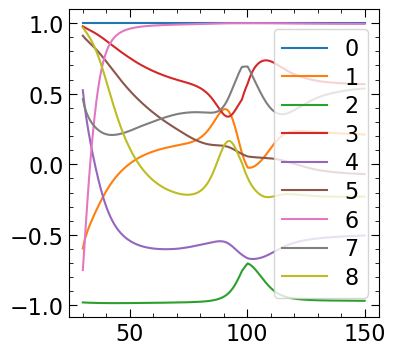

In [7]:
# read setup parameters
with open(Basis_Stem + '.pkl', 'rb') as f:
    params_setup = pickle.load(f)    
params_setup['file_stem'] = Basis_Stem
# initialize class
binet = BiSequential(params=params_setup)
# load network parameters from files
binet.load()

rvals = np.linspace(30,150,500)

basis = binet.extract_basis()
basis_func = basis.predict(binet.rv(rvals))
basis_func = np.concatenate((np.ones((1,basis_func.shape[1])),basis_func),axis=0) 
basis_func = basis_func[Use_Basis]

plt.figure(figsize=(4,4))
for b in range(N_Basis):
    plt.plot(rvals,basis_func[b],label=str(Use_Basis[b]))
plt.minorticks_on()
plt.legend()
plt.show()

## MCMC 

### Info dictionary definition

In [8]:
Rescale = 1e3
Modify_Data = True # default True
VaryMC = True # default True

Accuracy = 'mid' # 'low','mid' or 'high'. Default 'mid', giving <~3% error on quadrupole

id_str = Sample_Root + Sample + '/mcmc' + File_Body
if Include_Sig2Obs:
    id_str += '_inclSig2obs'
if not Modify_Data:
    id_str += '_unmod'
if Accuracy != 'mid':
    id_str += '_'+Accuracy+'acc'
if L_Max < 3:
    id_str += '_LMax{0:d}'.format(L_Max)
    
Run_Cobaya = True
Resume = False

Max_Samples = 10000000 
Rminus1_Stop = 0.01 # 0.01
Rminus1_CL_Stop = 0.05 # 0.05; arXiv:2602.14533 used 0.035/0.04
Rminus1_CL_Level = 0.95 # 95

Burn_In = 0

info = {}
info['likelihood'] = {'zelsmear.ZeldovichSmearingLike':
                      {'python_path':Like_Dir,
                       'rescale':Rescale,
                       'L_Max':L_Max,
                       'modify_data':Modify_Data,
                       'include_Sig2obs':Include_Sig2Obs,
                       'scales_file':Scales_File,
                       'data_file':Data_File,
                       'cov_file':Cov_File
                      }}

info['theory'] = {'zelsmear.ZeldovichSmearingTheory':
                  {'python_path':Like_Dir,
                   'stop_at_error': True,
                   'use_basis': Use_Basis,
                   'basis_stem':Basis_Stem,
                   'accuracy':Accuracy,
                   'n_r':100, 
                   # 100 gives LP convergence error ~0.1%, i.e. 3x smaller than DESI expectation
                   # 300 gives ~0.03%, 1000 is converged
                   'scales_file':Scales_File,
                   'L_Max':L_Max,
                   'modify_data':Modify_Data,
                   'include_Sig2obs':Include_Sig2Obs
                  }}

W_Names = ['w_{0:d}'.format(m) for m in Use_Basis] 

Params_List = ['beta','sigv']
Latex_List = ['\\beta','\\sigma_{\\rm v}']
Defaults_List = [beta_fid,sigv_fid]
proposal_list = [0.01,0.01]

Params_List.extend(W_Names)
Latex_List.extend(W_Names)
Defaults_List.extend(W_defaults) 
proposal_list.extend([0.001]*N_Basis)

Params_List += ['b','B1st','Bvst','sigma','AMC']
Latex_List += ['b','B_{1\\ast}','B_{v\\ast}','\\sigma','A_{\\rm MC}']
Defaults_List += [b_fid,0.0,0.0,sigma_fid,0.0] 
proposal_list += [0.002,0.02,0.02,0.01,0.01]

if L_Max > 1:
    Params_List += ['qbar2']
    Latex_List += ['\\bar q^{(2)}']
    Defaults_List += [0.0] 
    proposal_list += [None] if (Modify_Data & (L_Max == 2)) else [0.002]
    if L_Max == 3:
        Params_List += ['qbar4']
        Latex_List += ['\\bar q^{(4)}']
        Defaults_List += [0.0] 
        proposal_list += [None] if Modify_Data else [0.002]

if Include_Sig2Obs:
    Params_List += ['fv']
    Latex_List += ['f_{\\rm v}']
    Defaults_List += [fv_prior[0]]  
    proposal_list += [0.0002]

Derived_List = ['peak','LP','ZC']
Derived_Latex = ['r_{\\rm peak}','r_{\\rm LP}','r_{\\rm ZC}']
Derived_List = ['f'] + Derived_List
Derived_Latex = ['f'] + Derived_Latex

Delta_param = 0.001 # percentage variation for reference point

info['params'] = {}
for p in range(len(Params_List)):
    param = Params_List[p]
    proposal = proposal_list[p]
    defval = Defaults_List[p]
    
    info['params'][param] = {'ref':{'min':defval-Delta_param*np.fabs(defval),
                                    'max':defval+Delta_param*np.fabs(defval)},
                             'proposal':proposal,'latex':Latex_List[p]}
    if param == 'AMC':
        if VaryMC:
            info['params'][param] = {'ref':{'min':defval-Delta_param*np.fabs(defval),
                                            'max':defval+Delta_param*np.fabs(defval)},
                                     'proposal':proposal,'latex':Latex_List[p]}
        else:
            info['params'][param] = defval                
    if (param == 'qbar2'):
        if Modify_Data & (L_Max == 2):
            info['params'][param] = defval
        else:
            info['params'][param] = {'ref':{'min':defval-Delta_param*np.fabs(defval),
                                            'max':defval+Delta_param*np.fabs(defval)},
                                     'proposal':proposal,'latex':Latex_List[p]}
    if (param == 'qbar4'):
        if Modify_Data:
            info['params'][param] = defval                
        else:
            info['params'][param] = {'ref':{'min':defval-Delta_param*np.fabs(defval),
                                            'max':defval+Delta_param*np.fabs(defval)},
                                     'proposal':proposal,'latex':Latex_List[p]}
            
###############################
# set priors
###############################
info['params']['beta']['prior'] = {'min':-1.0,'max':1.0} # was -10,10
info['params']['sigv']['prior'] = {'min':0.0,'max':12.0}

for w in range(len(W_Names)):
    wname = W_Names[w]
    w_mean,w_std = W_defaults[w],(b_fid*growth_fid)**2*basis_prior[str(w)][1]
    info['params'][wname]['prior'] = {'dist':'norm','loc':w_mean,'scale':w_std} 
    
info['params']['b']['prior'] =  {'dist':'norm','loc':b_prior[0],'scale':b_prior[1]}
info['params']['B1st']['prior'] = {'min':-100.0,'max':100.0}
info['params']['Bvst']['prior'] = {'min':-100.0,'max':100.0}
info['params']['sigma']['prior'] = {'min':0.0,'max':12.0} # was {'min':0.0,'max':20.0}
if VaryMC:
    info['params']['AMC']['prior'] = {'dist':'norm','loc':0.0,'scale':0.05}
if L_Max > 1:
    if (not Modify_Data) | (L_Max == 3):
        # note L_Max==3 not 2
        info['params']['qbar2']['prior'] = {'min':-2.0,'max':2.0}
    if (L_Max == 3) & (not Modify_Data):
        info['params']['qbar4']['prior'] = {'min':-2.0,'max':2.0}
if Include_Sig2Obs:
    info['params']['fv']['prior'] = {'dist':'norm','loc':fv_prior[0],'scale':fv_prior[1]}

for d in range(len(Derived_List)):
    dpar = Derived_List[d]
    info['params'][dpar] = {'latex':Derived_Latex[d]}

info['sampler'] = {'mcmc':
                   {'learn_proposal': True,
                    'measure_speeds': True,
                    'max_samples': Max_Samples,
                    'max_tries': 1000,
                    'Rminus1_stop': Rminus1_Stop,
                    'Rminus1_cl_stop': Rminus1_CL_Stop,
                    'Rminus1_cl_level': Rminus1_CL_Level,
                    'burn_in': Burn_In}}

info_output = 'stats/chains/' 
info_output += 'varymc/' if VaryMC else 'nomc/'
info_output += id_str
info['output'] = info_output
if Resume:
    info["resume"] = True
else:
    info["force"] = True
print(info['output'])

stats/chains/varymc/AbacusSummit/base_c000/DESI-LRG2/mcmc_LMax3_lgMmin12.90_z0.800_inclSig2obs


### Theory class test

[model] *WARNING* Ignored blocks/options: ['sampler', 'output', 'force']
Setting up 20,6 layer feed-forward bi-neural network
... ... expecting data dim = 1, theta dim = 2, output dim = 1
... ... NNa using hidden layers of sizes [8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8]
... ... ... and activations [relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,tanh,tanh,tanh,tanh,tanh]
... ... NNw using hidden layers of sizes [3,3,3,3,3,9]
... ... ... and activations [tanh,tanh,tanh,tanh,tanh,tanh]
... ... using loss function 'square'
... ... not using any regularization
... ... not using any weight decay in NNa
... ... not using any weight decay in NNw
Extracting basis functions as NN...
... extracting basis functions from NNa
... setting up 20 layer feed-forward neural network
Warning!: last activation tanh seems inconsistent with square loss. Proceed with caution!
... ... expecting data dim = 1, target dim = 8
... ... using hidden layers of sizes [8,8,8,8,8,8,8,8,8,8,8,8

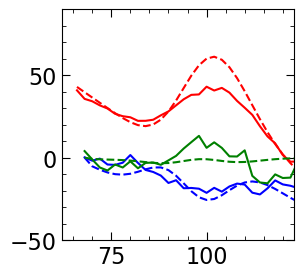

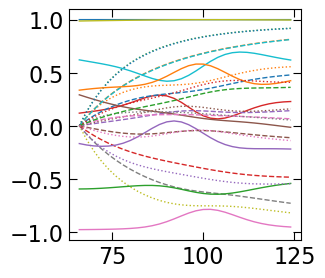

Sig2obs:
...  data: [27.36977  10.91014  -2.260074]
... error: [0.59190861 1.48805331 1.96910468]
... model: [27.94859209 11.96471889  0.62626506]


In [10]:
if not Resume:
    model = get_model(info)
    like = model.likelihood['zelsmear.ZeldovichSmearingLike']
    theory = model.theory['zelsmear.ZeldovichSmearingTheory']
    dp_test = {Params_List[p]:Defaults_List[p] for p in range(len(Params_List))}
    point = dict(zip(model.parameterization.sampled_params(),
                     model.prior.sample(ignore_external=True)[0]))
    point.update({key:dp_test[key] for key in point.keys()})
    print(model.logposterior(point))

    if Include_Sig2Obs:
        data = np.concatenate((np.loadtxt(Data_File[0]).T[0],np.loadtxt(Data_File[1])))
    else:
        data = np.loadtxt(Data_File)
    cov_data = np.loadtxt(Cov_File)
    data,cov_data = like.organize_data(data,cov_data)
    xiNLell = model.provider.get_model()*like.rescale
    if Include_Sig2Obs:
        xiNLell[:L_Max] /= like.rescale
    print(xiNLell.shape,data.shape,cov_data.shape)
    # print('model:',xiNLell)
    # print('data:',data)
    # print('data:',like.data)

    residual = data - xiNLell
    z = linalg.cho_solve((like.L,True),residual) # solves (L L^T) z = residual or z = C^-1 residual
    chi2 = np.dot(residual,z)
    print('chi2:',chi2)

    xiNLell_test = like.wrap_model(xiNLell)
    data = like.wrap_model(data)
    # print('wrapped model:',xiNLell_test)
    # print('wrapped data:',data)
    
    plt.figure(figsize=(3,3))
    plt.xlim(62,123)
    if Modify_Data:
        plt.ylim(-50,90)
    else:
        plt.ylim(-120,120)
    off = 1 if Modify_Data else 0
    offset = 1 if Include_Sig2Obs else 0
    plt.plot(like.svals,like.svals**2*data[offset]/like.rescale,'r-')
    plt.plot(like.svals,like.svals**2*xiNLell_test[offset]/like.rescale,'r--')
    if L_Max > 1:
        plt.plot(like.svals[off:],like.svals[off:]**2*data[offset+1]/like.rescale,'b-')
        plt.plot(like.svals[off:],like.svals[off:]**2*xiNLell_test[offset+1]/like.rescale,'b--')
        if L_Max == 3:
            plt.plot(like.svals[off:],like.svals[off:]**2*data[offset+2]/like.rescale,'g-')
            plt.plot(like.svals[off:],like.svals[off:]**2*xiNLell_test[offset+2]/like.rescale,'g--')
    plt.minorticks_on()
    plt.show()

    lam = theory.calc_lambda(sigma_fid)
    if L_Max > 1:
        lam_b,lam_bb = theory.calc_lambda_bars(sigma_fid)
    plt.figure(figsize=(3,3))
    for b in range(N_Basis):
        plt.plot(theory.svals,lam[b],lw=1,ls='-',label=str(Use_Basis[b]))
        if L_Max > 1:
            plt.plot(theory.svals,lam_b[b],lw=1,ls='--')
            if L_Max == 3:
                plt.plot(theory.svals,lam_bb[b],lw=1,ls=':')
    # plt.legend()
    plt.show()
    del lam,lam_b,lam_bb

    if Include_Sig2Obs:
        print('Sig2obs:')
        print('...  data:',data[0])
        print('... error:',np.sqrt(np.diag(cov_data)[:L_Max]))
        print('... model:',xiNLell_test[0])

### Run chains!

In [ ]:
if Run_Cobaya:
    start_time = time()
    # comm = MPI.COMM_WORLD
    # rank = comm.Get_rank()
    success = False
    try:
        upd_info, sampler = run(info,resume=Resume)#,allow_changes=True)
        success = True
    except LoggedError as err:
        pass
    # success = all(comm.allgather(success))
    if not success: # and rank == 0:
        print("Sampling failed!")

    ut.time_this(start_time)
else:
    print('Chains (hopefully) exist!')

[output] Output to be read-from/written-into folder 'stats/chains/varymc/AbacusSummit/base_c000/DESI-LRG2', with prefix 'mcmc_LMax3_lgMmin12.90_z0.800_inclSig2obs'
Setting up 20,6 layer feed-forward bi-neural network
... ... expecting data dim = 1, theta dim = 2, output dim = 1
... ... NNa using hidden layers of sizes [8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8]
... ... ... and activations [relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,tanh,tanh,tanh,tanh,tanh]
... ... NNw using hidden layers of sizes [3,3,3,3,3,9]
... ... ... and activations [tanh,tanh,tanh,tanh,tanh,tanh]
... ... using loss function 'square'
... ... not using any regularization
... ... not using any weight decay in NNa
... ... not using any weight decay in NNw
Extracting basis functions as NN...
... extracting basis functions from NNa
... setting up 20 layer feed-forward neural network
Warning!: last activation tanh seems inconsistent with square loss. Proceed with caution!
... ... expecting

## Plots

In [ ]:
Save_Fig = False

In [ ]:
model = get_model(info)
Burn_Frac = 0.3
rng = np.random.RandomState(42)
dim = N_Basis + 7
if L_Max > 1:
    dim += 1
    if L_Max == 3:
        dim += 1
if Include_Sig2Obs:
    dim += 1
if not VaryMC:
    dim -= 1 # don't sample AMC
if Modify_Data & (L_Max > 1):
        dim -= 1 # don't sample qbar2 (for L_Max==2) or qbar4 (for L_Max==3)

Scales = np.loadtxt(Scales_File)
Ndata = Scales.size*L_Max
if Modify_Data & (L_Max > 1):
    Ndata -= 1
    if L_Max == 3:
        Ndata -= 1
if Include_Sig2Obs:
    Ndata += L_Max
dof = Ndata - dim
print(dim,dof)        

plot_param_list = ['beta','sigv']
plot_param_list.extend(W_Names)
plot_param_list += ['b','B1st','Bvst','sigma']
if VaryMC:
    plot_param_list += ['AMC']
if L_Max > 1:
    if (not Modify_Data) | (L_Max == 3):
        # note L_Max==3 not 2
        plot_param_list += ['qbar2']
    if (L_Max == 3) & (not Modify_Data):
        plot_param_list += ['qbar4']
if Include_Sig2Obs:
    plot_param_list += ['fv']
plot_param_list += Derived_List

start_time = time()

gd_sample = loadMCSamples(os.path.abspath(info["output"]),settings={'ignore_rows':Burn_Frac})
gd_sample.label = 'MCMC'
mcmc_covmat = gd_sample.getCovMat().matrix[:dim, :dim]

sample = gd_sample.samples
    
sample = sample.T
ibest = sample[-2].argmin()
mcmc_best = gd_sample.samples[ibest]
mcmc_chi2 = mcmc_best[-1]
mcmc_best = mcmc_best[:dim+len(Derived_List)].copy()
pval = sysp.gammainc(mcmc_chi2/2,dof/2)

mcmc_sig = np.sqrt(np.diag(mcmc_covmat))

print('MCMC...')
print(plot_param_list)
print("... best fit  = ( "+','.join(['%.4e' % (pval,) for pval in mcmc_best])+" )")
print("... std dev   = ( "+','.join(['%.4e' % (pval,) for pval in mcmc_sig])+" )")
print("... chi2_best,dof,chi2_red,pval: {0:.3f},{1:d},{2:.3f},{3:.3e}".format(mcmc_chi2,dof,mcmc_chi2/dof,pval))

###################################################
# All params
Subplot_Size = 1.2
gdplot = gdplt.get_subplot_plotter(subplot_size=Subplot_Size)
gdplot.settings.num_plot_contours = 3
gdplot.settings.axes_fontsize = FS3
gdplot.settings.axes_labelsize = FS2
gdplot.settings.title_limit_fontsize = FS2 

gdplot.triangle_plot([gd_sample], plot_param_list,
                     filled=[True],contour_colors=['indigo'],legend_loc='upper center',
                     markers=mcmc_best[:dim+len(Derived_List)],
                     marker_args={'c': 'indigo','ls': '--','lw': 1.5,'alpha': 0.6},
                     title_limit=1)
for par_y in range(dim+len(Derived_List)):
    str_y = plot_param_list[par_y]
    ax = gdplot.subplots[par_y,par_y]
    ax.axvline(mcmc_best[par_y],c='indigo',ls='--',lw=1.5,alpha=0.6)
    for par_x in range(par_y):
        str_x = plot_param_list[par_x]
        ax = gdplot.subplots[par_y,par_x]
        ax.scatter([mcmc_best[par_x]],[mcmc_best[par_y]],
                   marker='*',s=100,c='white')

if Save_Fig:
    filename = 'contours_' + id_str 
    filename += '_varymc' if VaryMC else '_nomc'
    filename += '.pdf'
    pdir = (Plots_Dir + 'varymc/') if VaryMC else (Plots_Dir + 'nomc/')
    print('Writing to file: '+pdir+filename)
    gdplot.export(fname=filename,adir=pdir)
    
###################################################
# Cosmo params
Cosmo_List = ['sigv','f'] 
Cosmo_Inds = [1,dim] 
# Cosmo_Truth = [sigv,beta*dp['b']] 

Cosmo_List += ['LP','ZC']
Cosmo_Inds += [-2,-1]
# Cosmo_Truth += [rLP_true,rZC_true]

print(Cosmo_List)#,Cosmo_Truth)

Subplot_Size = 1.6
gdplot = gdplt.get_subplot_plotter(subplot_size=Subplot_Size)
gdplot.settings.num_plot_contours = 3
gdplot.settings.axes_fontsize = FS3
gdplot.settings.axes_labelsize = FS2
gdplot.settings.title_limit_fontsize = FS2 

gdplot.triangle_plot([gd_sample],Cosmo_List,
                     filled=[True],contour_colors=['indigo'],legend_loc='upper center',
                     markers=mcmc_best[Cosmo_Inds],
                     marker_args={'c': 'indigo','ls': '--','lw': 1.5,'alpha': 0.6},
                     title_limit=1)
for par_y in range(len(Cosmo_List)):
    str_y = Cosmo_List[par_y]
    ax = gdplot.subplots[par_y,par_y]
    ax.axvline(mcmc_best[Cosmo_Inds[par_y]],c='indigo',ls='--',lw=1.5,alpha=0.6)
    # ax.axvline(Cosmo_Truth[par_y],c='goldenrod',ls=':',lw=1.5,alpha=0.6)
    for par_x in range(par_y):
        str_x = Cosmo_List[par_x]
        ax = gdplot.subplots[par_y,par_x]
        ax.scatter([mcmc_best[Cosmo_Inds[par_x]]],[mcmc_best[Cosmo_Inds[par_y]]],
                   marker='*',s=100,c='white')
        # ax.scatter([Cosmo_Truth[par_x]],[Cosmo_Truth[par_y]],
        #            marker='*',s=80,c='goldenrod')
        # ax.axvline(Cosmo_Truth[par_x],c='goldenrod',ls=':',lw=1.5,alpha=0.6)
        # ax.axhline(Cosmo_Truth[par_y],c='goldenrod',ls=':',lw=1.5,alpha=0.6)

if Save_Fig:
    filename = 'contours_' + id_str 
    filename += '_varymc' if VaryMC else '_nomc'
    filename += '_cosmo.pdf'
    pdir = (Plots_Dir + 'varymc/') if VaryMC else (Plots_Dir + 'nomc/')
    print('Writing to file: '+pdir+filename)
    gdplot.export(fname=filename,adir=pdir)

###################################################
# SDBMC params
SDBMC_List = ['B1st','Bvst','sigma'] 
SDBMC_Inds = [N_Basis+3,N_Basis+4,N_Basis+5] 
# +3 since beta,sigv,b varied

if VaryMC:
    SDBMC_List += ['AMC']
    SDBMC_Inds += [N_Basis+6] 

print(SDBMC_List)

Subplot_Size = 1.6
gdplot = gdplt.get_subplot_plotter(subplot_size=Subplot_Size)
gdplot.settings.num_plot_contours = 3
gdplot.settings.axes_fontsize = FS3
gdplot.settings.axes_labelsize = FS2
gdplot.settings.title_limit_fontsize = FS2 

gdplot.triangle_plot([gd_sample],SDBMC_List,
                     filled=[True],contour_colors=['indigo'],legend_loc='upper center',
                     markers=mcmc_best[SDBMC_Inds],
                     marker_args={'c': 'indigo','ls': '--','lw': 1.5,'alpha': 0.6},
                     title_limit=1)
for par_y in range(len(SDBMC_List)):
    str_y = SDBMC_List[par_y]
    ax = gdplot.subplots[par_y,par_y]
    ax.axvline(mcmc_best[SDBMC_Inds[par_y]],c='indigo',ls='--',lw=1.5,alpha=0.6)
    for par_x in range(par_y):
        str_x = SDBMC_List[par_x]
        ax = gdplot.subplots[par_y,par_x]
        ax.scatter([mcmc_best[SDBMC_Inds[par_x]]],[mcmc_best[SDBMC_Inds[par_y]]],
                   marker='*',s=100,c='white')

if Save_Fig:
    filename = 'contours_' + id_str 
    filename += '_varymc' if VaryMC else '_nomc'
    filename += '_sdbmc.pdf'
    pdir = (Plots_Dir + 'varymc/') if VaryMC else (Plots_Dir + 'nomc/')
    print('Writing to file: '+pdir+filename)
    gdplot.export(fname=filename,adir=pdir)
###################################################

###################################################
# SDBMC+Cosmo params
Mixed_List = ['sigv','LP','b','B1st','Bvst']
Mixed_Inds = [1,-2,N_Basis+2,N_Basis+3,N_Basis+4]
# +3 since beta,sigv,b varied

if VaryMC:
    Mixed_List += ['AMC']
    Mixed_Inds += [N_Basis+6]

print(Mixed_List)

Subplot_Size = 1.6
gdplot = gdplt.get_subplot_plotter(subplot_size=Subplot_Size)
gdplot.settings.num_plot_contours = 3
gdplot.settings.axes_fontsize = FS3
gdplot.settings.axes_labelsize = FS2
gdplot.settings.title_limit_fontsize = FS2 

gdplot.triangle_plot([gd_sample],Mixed_List,
                     filled=[True],contour_colors=['indigo'],legend_loc='upper center',
                     markers=mcmc_best[Mixed_Inds],
                     marker_args={'c': 'indigo','ls': '--','lw': 1.5,'alpha': 0.6},
                     title_limit=1)
for par_y in range(len(Mixed_List)):
    str_y = Mixed_List[par_y]
    ax = gdplot.subplots[par_y,par_y]
    ax.axvline(mcmc_best[Mixed_Inds[par_y]],c='indigo',ls='--',lw=1.5,alpha=0.6)
    for par_x in range(par_y):
        str_x = Mixed_List[par_x]
        ax = gdplot.subplots[par_y,par_x]
        ax.scatter([mcmc_best[Mixed_Inds[par_x]]],[mcmc_best[Mixed_Inds[par_y]]],
                   marker='*',s=100,c='white')

if Save_Fig:
    filename = 'contours_' + id_str 
    filename += '_varymc' if VaryMC else '_nomc'
    filename += '_mixed.pdf'
    pdir = (Plots_Dir + 'varymc/') if VaryMC else (Plots_Dir + 'nomc/')
    print('Writing to file: '+pdir+filename)
    gdplot.export(fname=filename,adir=pdir)
###################################################


###################################################
# Best fit
stab = Scales.copy()
like = model.likelihood['zelsmear.ZeldovichSmearingLike']
theory = model.theory['zelsmear.ZeldovichSmearingTheory']
off = 1 if Include_Sig2Obs else 0

dp_best = {Params_List[p]:Defaults_List[p] for p in range(len(Params_List))}
cnt = 0
for param in plot_param_list[:dim]:
    dp_best[param] = mcmc_best[cnt]
    cnt += 1

point = dict(zip(model.parameterization.sampled_params(),
                 model.prior.sample(ignore_external=True)[0]))
point.update({key:dp_best[key] for key in point.keys()})
model.logposterior(point)
xiNLell_best = like.wrap_model(model.provider.get_model())
W_best = np.array([dp_best['w_{0:d}'.format(m)] for m in Use_Basis])
xilin_best = np.dot(theory.bfunc.T,W_best)/dp_best['b']**2
# xilin_true = (comul.growth)**2*co.calc_xi_lin(theory.rvals*h_true_by_h_fid)

dp_nomc = copy.deepcopy(dp_best)
dp_nomc['AMC'] = 0.0 
point = dict(zip(model.parameterization.sampled_params(),
                 model.prior.sample(ignore_external=True)[0]))
point.update({key:dp_nomc[key] for key in point.keys()})
model.logposterior(point)
xiNLell_nomc = like.wrap_model(model.provider.get_model())

N_Boot_Cobaya = np.min([1000,int(0.2*sample[0].size)])
Ind = gd_sample.random_single_samples_indices(random_state=42,max_samples=N_Boot_Cobaya)
N_Boot_Cobaya = Ind.size
print('N_Boot_Cobaya: ',N_Boot_Cobaya)

xiNLell_boot = np.zeros((N_Boot_Cobaya,like.Dim_Data),dtype=float)
xilin_boot = np.zeros((N_Boot_Cobaya,theory.rvals.size),dtype=float)

print('... extracting xiNL_ell stats from subsample')
for b in range(N_Boot_Cobaya):
    params_b = sample[:dim,Ind[b]] 
    dp_b = {Params_List[p]:Defaults_List[p] for p in range(len(Params_List))}
    cnt = 0
    for param in plot_param_list[:dim]:
        dp_b[param] = params_b[cnt]
        cnt += 1
    
    point = dict(zip(model.parameterization.sampled_params(),
                     model.prior.sample(ignore_external=True)[0]))
    point.update({key:dp_b[key] for key in point.keys()})
    model.logposterior(point)
    xiNLell_b = model.provider.get_model()
    xiNLell_boot[b] = xiNLell_b
    W_b = np.array([dp_b['w_{0:d}'.format(m)] for m in Use_Basis])
    xilin_boot[b] = np.dot(theory.bfunc.T,W_b)/dp_b['b']**2
    ut.status_bar(b,N_Boot_Cobaya)

xiNL_16pc = np.percentile(xiNLell_boot,16,axis=0)
xiNL_50pc = np.percentile(xiNLell_boot,50,axis=0)
xiNL_84pc = np.percentile(xiNLell_boot,84,axis=0)

xiNL_16pc = like.wrap_model(xiNL_16pc)
xiNL_50pc = like.wrap_model(xiNL_50pc)
xiNL_84pc = like.wrap_model(xiNL_84pc)

xilin_16pc = np.percentile(xilin_boot,16,axis=0)
xilin_50pc = np.percentile(xilin_boot,50,axis=0)
xilin_84pc = np.percentile(xilin_boot,84,axis=0)

del xiNLell_boot,xilin_boot
gc.collect()

data = np.loadtxt(Data_File)
cov_data = np.loadtxt(Cov_File)
data,cov_data = like.organize_data(data,cov_data)
data = like.wrap_model(data)
err = like.wrap_model(np.sqrt(np.diag(cov_data)))

cols = ['crimson','indigo','forestgreen']

plt.figure(figsize=(7,7))
plt.xlabel('$s\\,(h^{{-1}}\\,{{\\rm Mpc}})$')
plt.xlim(62,123)
if Modify_Data:
    plt.ylim(-50,90)
    ylabel = '$s^{{2}}\\,\\Delta\\xi^{{(\\ell)}}(s)$'
else:
    plt.ylim(-120,120)
    ylabel = '$s^{{2}}\\,\\xi^{{(\\ell)}}(s)$'
if Include_Sig2Obs:
    off_vert = 50
    ylabel += '$;\\,\\Sigma^{{(\\ell)2}}+{0:d}$'.format(off_vert)
ylabel += '$\\,\\,(h^{{-1}}{{\\rm Mpc}})^{{2}}$'
plt.ylabel(ylabel)
for L in range(L_Max):
    Imin_s = 1 if (Modify_Data & (L >= 1)) else 0
    stab_show = stab[Imin_s:]
    Label = 'best fit' if L==0 else None
    plt.plot(stab_show,stab_show**2*xiNLell_best[off+L],'-',lw=1,c=cols[L],label=Label)
    plt.fill_between(stab_show,stab_show**2*xiNL_84pc[off+L],stab_show**2*xiNL_16pc[off+L],color=cols[L],alpha=0.15)
    Label = 'no mc' if L==0 else None
    plt.plot(stab_show,stab_show**2*xiNLell_nomc[off+L],':',lw=1,c=cols[L],label=Label)

    if L==0:
        data_label = 'data'
    else:
        data_label = None
    plt.errorbar(stab_show,stab_show**2*data[off+L]/like.rescale,yerr=stab_show**2*err[off+L]/like.rescale,
                 c=cols[L],ls='none',capsize=5,marker='o',markersize=4,alpha=0.3,label=data_label)

if Include_Sig2Obs:
    Sigx = np.linspace(70,70+5*(L_Max-1),L_Max).astype(int) 
    plt.errorbar(Sigx,data[0]+off_vert,yerr=err[0],
                 marker='o',ls='none',c='teal',capsize=6,markersize=4,lw=1,alpha=0.3)
    plt.errorbar(Sigx+0.5,xiNL_50pc[0]+off_vert,yerr=[xiNL_50pc[0]-xiNL_16pc[0],xiNL_84pc[0]-xiNL_50pc[0]],
                 marker='none',ls='none',c='turquoise',capsize=4,markersize=0,lw=1,alpha=0.9)
    plt.scatter(Sigx+0.5,xiNLell_best[0]+off_vert,
                 marker='*',color='turquoise',s=40,alpha=0.6)
    
plt.text(65,55,'$\ell = 0$',fontsize=FS2,c=cols[0])
if L_Max > 1:
    plt.text(65,-18,'$\ell = 2$',fontsize=FS2,c=cols[1])
    if L_Max == 3:
        plt.text(96,25,'$\ell = 4$',fontsize=FS2,c=cols[2])
plt.text(65,-40,"$\\chi^{{2}}\\,/\\,{{\\rm dof}} = {0:.2f}\\,/\\,{1:d}\\,;\\,p = {2:.3f}$".format(mcmc_chi2,dof,pval),
         fontsize=FS3)

plt.legend(loc='upper right')
plt.minorticks_on()
if Save_Fig:
    filename = 'xiell_' + id_str 
    filename += '_varymc' if VaryMC else '_nomc'
    filename += '.pdf'
    if VaryMC:
        filename = 'varymc/' + filename
    else:
        filename = 'nomc/' + filename
    filename = Plots_Dir+filename
    print('Writing to file: '+filename)
    plt.savefig(filename,bbox_inches='tight')
plt.show()

# linear reconstruction
plt.figure(figsize=(7,7))
plt.xlabel('$r\\,(h^{{-1}}\\,{{\\rm Mpc}})$')
plt.xlim(25,155)
plt.ylim(-7,28)
ylabel = '$r^{{2}}\\,\\xi_{{\\rm lin}}(r)$'
ylabel += '$\\,\\,(h^{{-1}}{{\\rm Mpc}})^{{2}}$'
plt.ylabel(ylabel)

plt.plot(theory.rvals,theory.rvals**2*xilin_best,'-',lw=1.5,c='darkgoldenrod',label='best fit')
plt.plot(theory.rvals,theory.rvals**2*xilin_50pc,'--',lw=1.5,c='darkgoldenrod',label='median')
plt.fill_between(theory.rvals,theory.rvals**2*xilin_84pc,theory.rvals**2*xilin_16pc,color='goldenrod',alpha=0.15)

# plt.plot(theory.rvals,theory.rvals**2*xilin_true,'-',lw=2,c='crimson',label='ground truth')
plt.axhline(0.0,c='k',ls=':',lw=1)
ell_vals = '['
ell_vals += ','.join([str(l) for l in range(0,2*L_Max,2)])
ell_vals += ']'
plt.text(80,17,'linear reconstruction',fontsize=FS2)
plt.text(80,15,'at $z = {0:.1f}$ with $\\ell =$'.format(Redshift)+ell_vals,fontsize=FS2)
    
plt.legend(loc='upper right')
plt.minorticks_on()
if Save_Fig:
    filename = 'xilin_' + id_str 
    filename += '_varymc' if VaryMC else '_nomc'
    filename += '.pdf'
    if VaryMC:
        filename = 'varymc/' + filename
    else:
        filename = 'nomc/' + filename
    filename = Plots_Dir+filename
    print('Writing to file: '+filename)
    plt.savefig(filename,bbox_inches='tight')
plt.show()

ut.time_this(start_time)

In [ ]:
print(L_Max,Run_Cobaya,Resume,Save_Fig)